In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet import ResNet152, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [6]:
# Loading Resnet model
model = ResNet152(weights='imagenet')

In [7]:
image_folder = "dataset/"

# getting the first 10 image files from the folder
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))][:10]

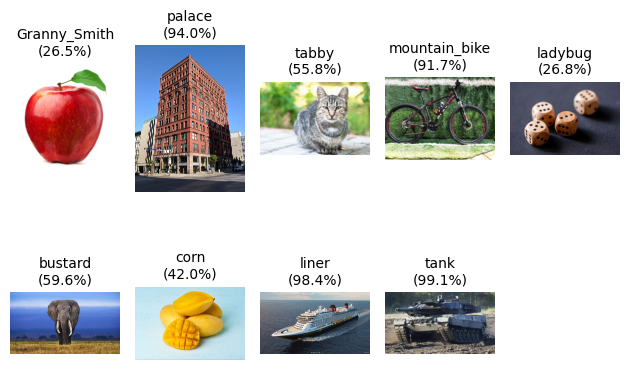

In [8]:
for i, img_file in enumerate(image_files):
    img_path = os.path.join(image_folder, img_file)
    
    img_for_model = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img_for_model)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x) 
    

    preds = model.predict(x, verbose=0)
    decoded_preds = decode_predictions(preds, top=1)[0]
    label = decoded_preds[0][1]
    confidence = decoded_preds[0][2] * 100
    
    plt.subplot(2, 5, i + 1)
    
    
    display_img = image.load_img(img_path)
    plt.imshow(display_img)
    
    plt.title(f"{label}\n({confidence:.1f}%)", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()